In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

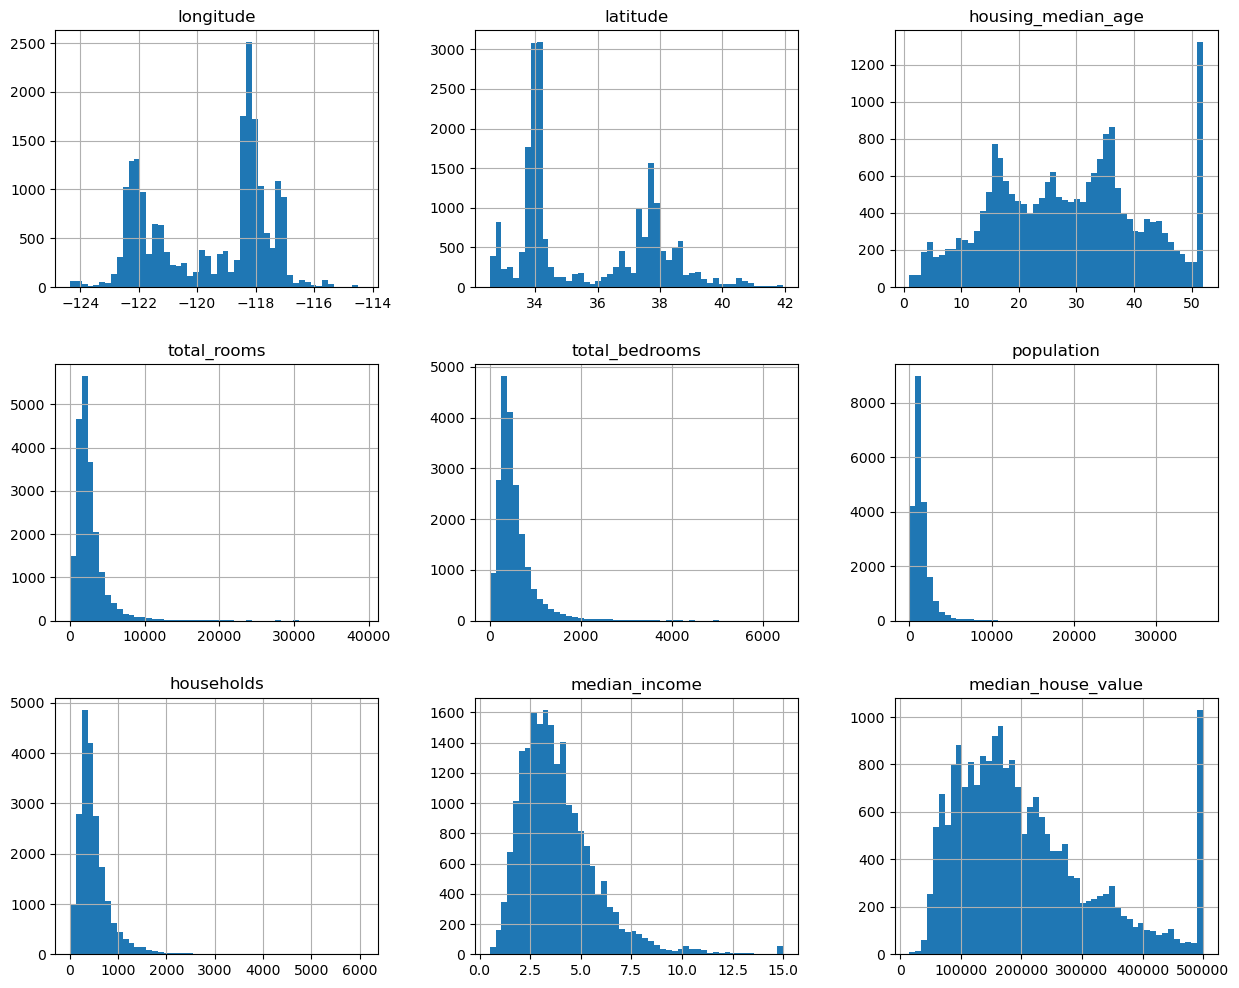

In [3]:
df=pd.read_csv('housing.csv')
df.hist(bins=50,figsize=(15,
                         12))


In [4]:
df["income_cat"]=pd.cut(df["median_income"],bins=(5),labels=(1,2,3,4,5))

In [5]:
train,test=train_test_split(df,test_size=0.2,stratify=df["income_cat"],random_state=42)

In [6]:
train.value_counts()

longitude  latitude  housing_median_age  total_rooms  total_bedrooms  population  households  median_income  median_house_value  ocean_proximity  income_cat
-121.05    38.92     34.0                2144.0       372.0           899.0       378.0       3.3021         158800.0            INLAND           1             1
-118.26    33.94     45.0                1080.0       218.0           850.0       237.0       2.2500         93400.0             <1H OCEAN        1             1
-117.80    33.74     30.0                3569.0       551.0           1540.0      537.0       5.2998         247200.0            <1H OCEAN        2             1
-118.27    33.98     30.0                1966.0       584.0           2028.0      535.0       1.6250         101500.0            <1H OCEAN        1             1
-122.12    37.40     32.0                3514.0       473.0           1583.0      480.0       10.3894        500001.0            NEAR BAY         4             1
                                 

In [7]:
df.value_counts()

longitude  latitude  housing_median_age  total_rooms  total_bedrooms  population  households  median_income  median_house_value  ocean_proximity  income_cat
-122.23    37.88     41.0                880.0        129.0           322.0       126.0       8.3252         452600.0            NEAR BAY         3             1
-122.22    37.86     21.0                7099.0       1106.0          2401.0      1138.0      8.3014         358500.0            NEAR BAY         3             1
-122.24    37.85     52.0                1467.0       190.0           496.0       177.0       7.2574         352100.0            NEAR BAY         3             1
-122.25    37.85     52.0                1274.0       235.0           558.0       219.0       5.6431         341300.0            NEAR BAY         2             1
                                         1627.0       280.0           565.0       259.0       3.8462         342200.0            NEAR BAY         2             1
                                 

In [8]:
train.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16341.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.571206,35.635415,28.671088,2631.917393,536.652408,1422.341025,498.091509,3.874310,206875.973232
std,2.001514,2.131420,12.576579,2175.859260,419.943165,1134.609372,379.670223,1.902947,115499.720137
min,-124.350000,32.540000,1.000000,8.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1444.000000,295.000000,789.000000,280.000000,2.562500,119400.000000
50%,-118.500000,34.260000,29.000000,2127.000000,435.000000,1164.500000,409.000000,3.534100,179500.000000
75%,-118.010000,37.710000,37.000000,3140.000000,645.000000,1720.000000,602.000000,4.742300,265000.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [9]:
train.info()


<class 'pandas.DataFrame'>
Index: 16512 entries, 1891 to 10749
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16512 non-null  float64 
 1   latitude            16512 non-null  float64 
 2   housing_median_age  16512 non-null  float64 
 3   total_rooms         16512 non-null  float64 
 4   total_bedrooms      16341 non-null  float64 
 5   population          16512 non-null  float64 
 6   households          16512 non-null  float64 
 7   median_income       16512 non-null  float64 
 8   median_house_value  16512 non-null  float64 
 9   ocean_proximity     16512 non-null  str     
 10  income_cat          16512 non-null  category
dtypes: category(1), float64(9), str(1)
memory usage: 1.4 MB


In [25]:
train.isna().any()
np.set_printoptions(suppress=True)

In [40]:

imputer=SimpleImputer(strategy="median")

train_col=train.select_dtypes(include=[np.number])
imputer.fit(train_col)
imputer.statistics_
x=pd.DataFrame(imputer.transform(train_col),columns=train_col.columns,index=train_col.index)


In [45]:
train=x

In [47]:


from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
train_encoded = encoder.fit_transform(
    train[["ocean_proximity"]]
)
train_encoded = pd.DataFrame(
    train_encoded.toarray(),
    columns=encoder.get_feature_names_out(),
    index=train.index
)
train_encoded.head()


KeyError: "None of [Index(['ocean_proximity'], dtype='str')] are in the [columns]"

In [39]:
train_encoded

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>